# 📊 EDA – Image Dataset (CIFAR-100)

**CO5085 – Assignment 1**

Mục đích: Khám phá và hiểu tập dữ liệu ảnh.

In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from collections import Counter

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Download Dataset

In [2]:
train_ds = datasets.CIFAR100(root='../data/image', train=True,  download=True, transform=transforms.ToTensor())
test_ds  = datasets.CIFAR100(root='../data/image', train=False, download=True, transform=transforms.ToTensor())
print(f'Train size: {len(train_ds)} | Test size: {len(test_ds)}')
print(f'Classes (first 10): {train_ds.classes[:10]}')
print(f'Image shape: {train_ds[0][0].shape}')

Train size: 50000 | Test size: 10000
Classes (first 10): ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']
Image shape: torch.Size([3, 32, 32])


## 2. Class Distribution

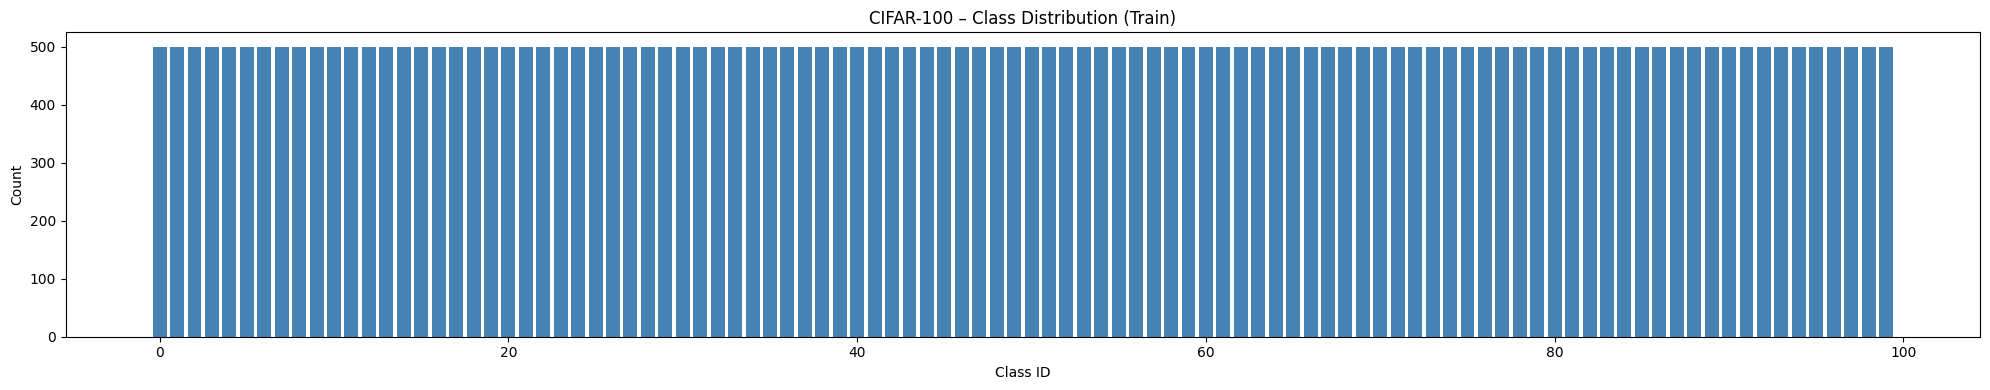

Min samples per class: 500 | Max: 500


In [3]:
labels = [y for _, y in train_ds]
counts = Counter(labels)
plt.figure(figsize=(20, 4))
plt.bar(range(100), [counts[i] for i in range(100)], color='steelblue')
plt.title('CIFAR-100 – Class Distribution (Train)')
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/cifar100_class_dist.png', dpi=150)
plt.show()
print(f'Min samples per class: {min(counts.values())} | Max: {max(counts.values())}')

## 3. Sample Images

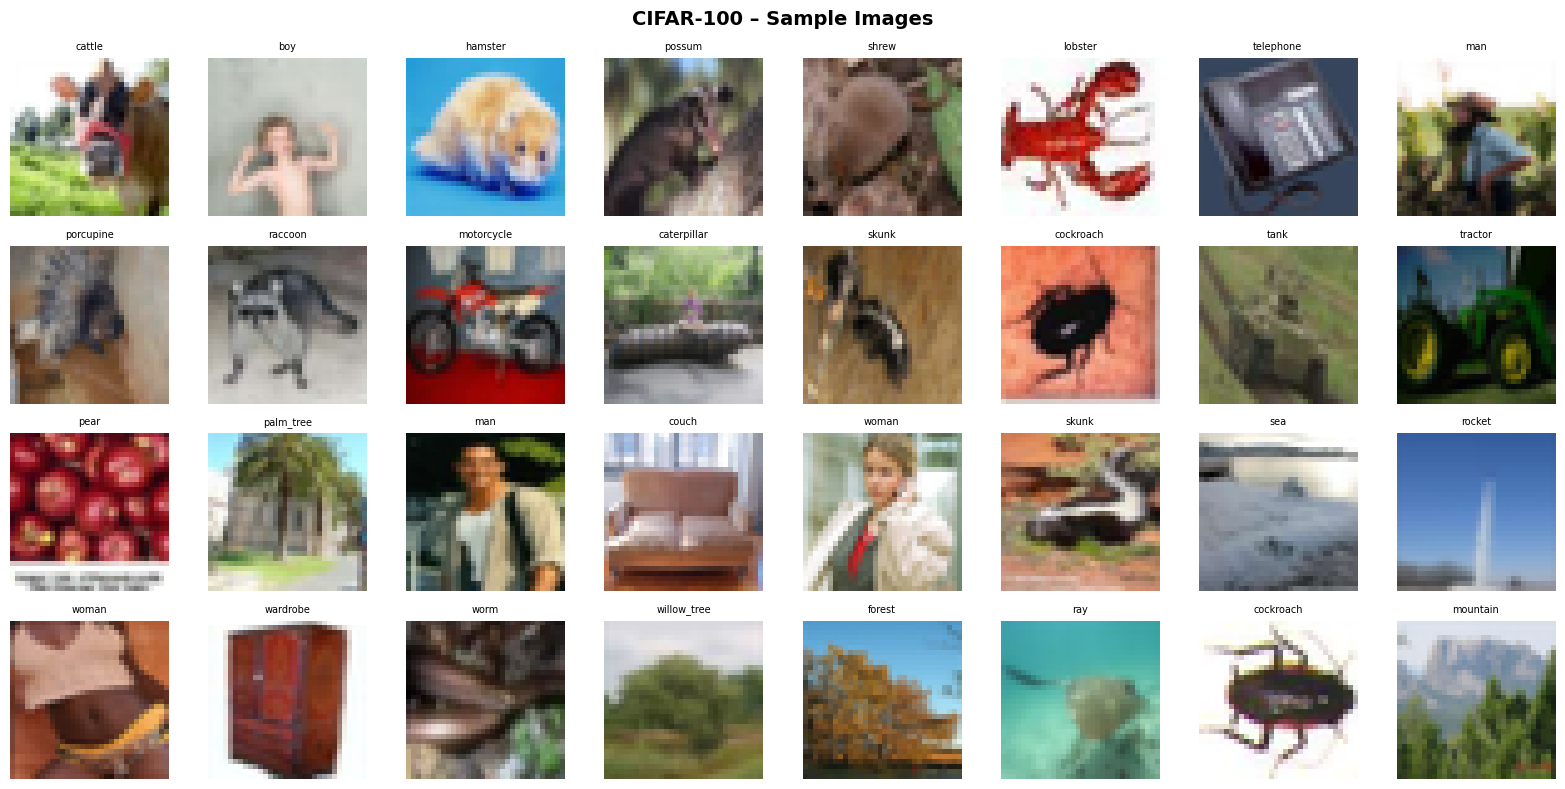

In [4]:
import torchvision
import torch

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img, label = train_ds[i * 37 % len(train_ds)]
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.set_title(train_ds.classes[label], fontsize=7)
    ax.axis('off')
plt.suptitle('CIFAR-100 – Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cifar100_samples.png', dpi=150)
plt.show()

## 4. Pixel Statistics

In [5]:
# Compute channel-wise mean and std (on a subset for speed)
subset = torch.stack([train_ds[i][0] for i in range(0, min(5000, len(train_ds)), 5)])
means = subset.mean(dim=[0, 2, 3])
stds  = subset.std(dim=[0, 2, 3])
print(f'Mean: {means.tolist()}')
print(f'Std:  {stds.tolist()}')

Mean: [0.5059431791305542, 0.4797546863555908, 0.43631982803344727]
Std:  [0.26368531584739685, 0.25488370656967163, 0.2754207253456116]


## 5. Augmentation Preview

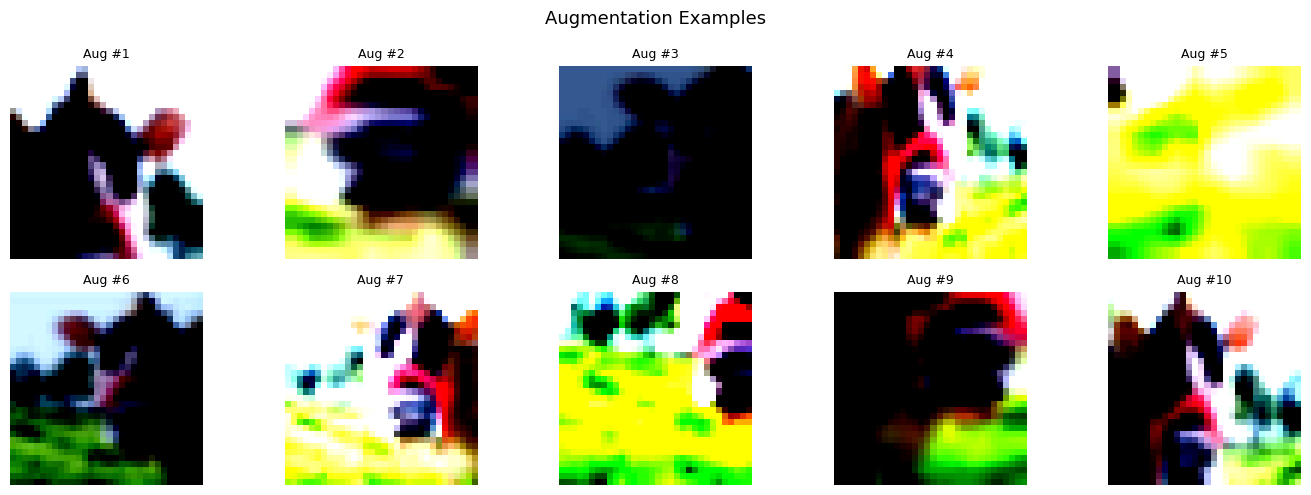

In [6]:
from torchvision import transforms
from datasets import get_image_transforms

base_img = transforms.ToPILImage()(train_ds[0][0])
aug = get_image_transforms(train=True, img_size=32)

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(aug(base_img).permute(1, 2, 0).clamp(0, 1))
    ax.set_title(f'Aug #{i+1}', fontsize=9)
    ax.axis('off')
plt.suptitle('Augmentation Examples', fontsize=13)
plt.tight_layout()
plt.savefig('../results/augmentation_preview.png', dpi=150)
plt.show()